# Ảnh hưởng của tồn kho với lợi nhuận

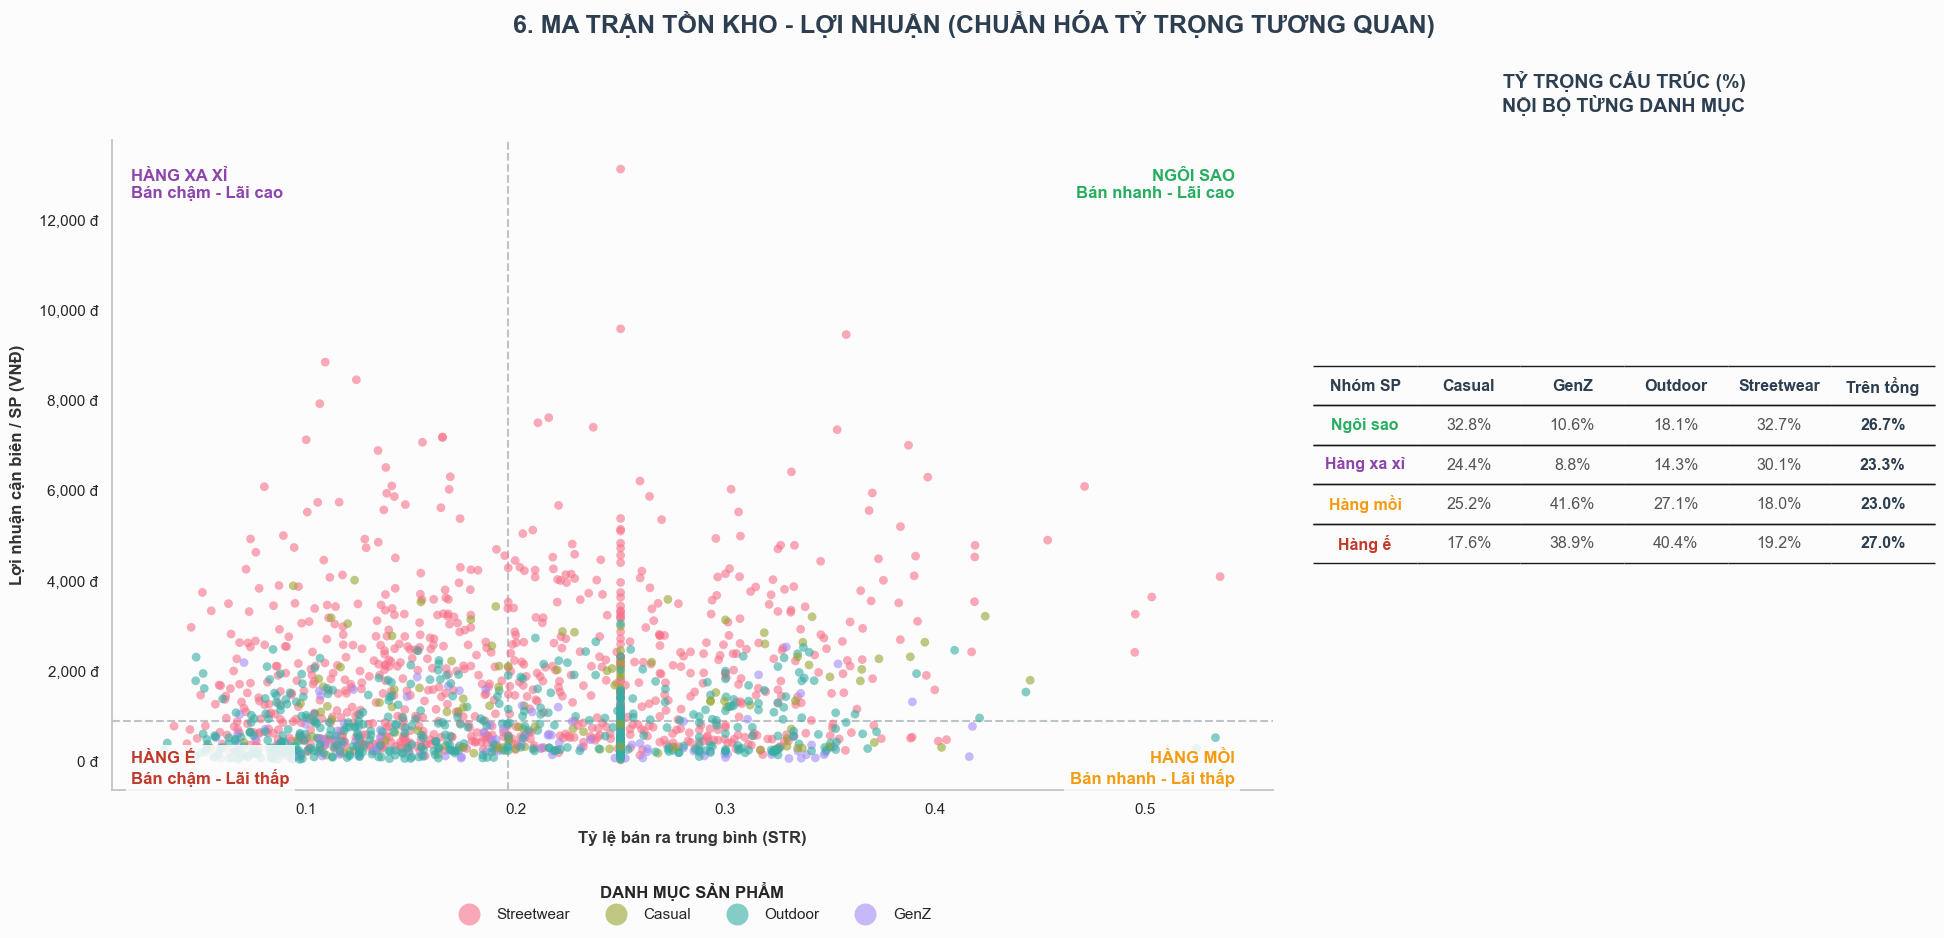

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Hàm format tiền tệ
def format_vnd_modern(val, pos=None):
    abs_val = abs(val)
    sign = "-" if val < 0 else ""
    if abs_val >= 1e9:
        return f"{sign}{abs_val/1e9:.1f}B đ"
    elif abs_val >= 1e6:
        return f"{sign}{abs_val/1e6:.1f}M đ"
    else:
        return f"{sign}{abs_val:,.0f} đ"

sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

try:
    # 1. ĐỌC & XỬ LÝ DỮ LIỆU
    products = pd.read_csv('../dataset/products.csv')
    inventory = pd.read_csv('../dataset/inventory.csv')

    products['Marginal_Profit'] = products['price'] - products['cogs']
    inv_summary = inventory.groupby('product_id')['sell_through_rate'].mean().reset_index()
    
    df_matrix = pd.merge(products, inv_summary, on='product_id', how='inner').dropna(subset=['sell_through_rate', 'Marginal_Profit'])

    median_str = df_matrix['sell_through_rate'].median()
    median_profit = df_matrix['Marginal_Profit'].median()

    # 2. PHÂN LOẠI SẢN PHẨM
    conditions = [
        (df_matrix['sell_through_rate'] > median_str) & (df_matrix['Marginal_Profit'] > median_profit),
        (df_matrix['sell_through_rate'] <= median_str) & (df_matrix['Marginal_Profit'] > median_profit),
        (df_matrix['sell_through_rate'] > median_str) & (df_matrix['Marginal_Profit'] <= median_profit),
        (df_matrix['sell_through_rate'] <= median_str) & (df_matrix['Marginal_Profit'] <= median_profit)
    ]
    
    choices = ['Ngôi sao', 'Hàng xa xỉ', 'Hàng mồi', 'Hàng ế']
    df_matrix['Quadrant'] = np.select(conditions, choices, default='Khác')
    
    # LẬP BẢNG CHÉO (RAW DATA)
    cross_tab_raw = pd.crosstab(df_matrix['Quadrant'], df_matrix['category']).reindex(choices).fillna(0)
    
    # Thêm cột "Trên tổng" để làm mốc đối chiếu chuẩn (Baseline)
    cross_tab_raw['Trên tổng'] = cross_tab_raw.sum(axis=1)
    
    # 3. CHUẨN HÓA DỮ LIỆU THÀNH % (NORMALIZATION THEO CỘT)
    # Lấy giá trị từng ô chia cho tổng của cột đó
    cross_tab_pct = cross_tab_raw.div(cross_tab_raw.sum(axis=0), axis=1) * 100
    
    # Chuẩn bị dữ liệu hiển thị (Format thành chuỗi có dấu %)
    table_data = []
    for index, row in cross_tab_pct.iterrows():
        formatted_row = [index] + [f"{val:.1f}%" for val in row.values]
        table_data.append(formatted_row)
        
    col_labels = ['Nhóm SP'] + cross_tab_pct.columns.tolist()

    # 4. THIẾT LẬP LAYOUT
    fig = plt.figure(figsize=(23, 10)) 
    gs = fig.add_gridspec(1, 3, wspace=0.15) 
    ax1 = fig.add_subplot(gs[0, :2])         
    ax2 = fig.add_subplot(gs[0, 2])          

    # ==========================================
    # PHẦN 1: VẼ BIỂU ĐỒ (TRÊN AX1)
    # ==========================================
    sns.scatterplot(data=df_matrix, x='sell_through_rate', y='Marginal_Profit', hue='category', 
                    palette='husl', s=40, alpha=0.6, linewidth=0, zorder=2, ax=ax1)

    ax1.axvline(median_str, color='#bdc3c7', linestyle='--', linewidth=1.5, zorder=1)
    ax1.axhline(median_profit, color='#bdc3c7', linestyle='--', linewidth=1.5, zorder=1)

    x_min, x_max = ax1.get_xlim()
    y_min, y_max = ax1.get_ylim()
    text_bbox = dict(facecolor='#fcfcfc', alpha=0.85, edgecolor='none', pad=4)

    ax1.text(x_max - (x_max - median_str)*0.05, y_max - (y_max - median_profit)*0.05, 
            'NGÔI SAO\nBán nhanh - Lãi cao', fontsize=12, fontweight='bold', color='#27ae60', ha='right', va='top', bbox=text_bbox, zorder=10)
    ax1.text(x_min + (median_str - x_min)*0.05, y_max - (y_max - median_profit)*0.05, 
            'HÀNG XA XỈ\nBán chậm - Lãi cao', fontsize=12, fontweight='bold', color='#8e44ad', ha='left', va='top', bbox=text_bbox, zorder=10)
    ax1.text(x_max - (x_max - median_str)*0.05, y_min + (median_profit - y_min)*0.05, 
            'HÀNG MỒI\nBán nhanh - Lãi thấp', fontsize=12, fontweight='bold', color='#f39c12', ha='right', va='bottom', bbox=text_bbox, zorder=10)
    ax1.text(x_min + (median_str - x_min)*0.05, y_min + (median_profit - y_min)*0.05, 
            'HÀNG Ế\nBán chậm - Lãi thấp', fontsize=12, fontweight='bold', color='#c0392b', ha='left', va='bottom', bbox=text_bbox, zorder=10)

    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax1.set_ylabel('Lợi nhuận cận biên / SP (VNĐ)', fontsize=12, fontweight='bold', color='#333333', labelpad=10)
    ax1.set_xlabel('Tỷ lệ bán ra trung bình (STR)', fontsize=12, fontweight='bold', color='#333333', labelpad=10)
    
    for spine in ['top', 'right']:
        ax1.spines[spine].set_visible(False)
    ax1.spines['left'].set_color('#bdc3c7')
    ax1.spines['bottom'].set_color('#bdc3c7')

    ax1.legend(title='DANH MỤC SẢN PHẨM', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=6, frameon=False, fontsize=11, title_fontproperties={'weight':'bold'}, markerscale=2.5)

    # ==========================================
    # PHẦN 2: VẼ BẢNG THỐNG KÊ (CHUẨN HÓA % TRÊN AX2)
    # ==========================================
    ax2.axis('off')
    
    row_colors = ['#27ae60', '#8e44ad', '#f39c12', '#c0392b']
    
    table = ax2.table(cellText=table_data, 
                      colLabels=col_labels, 
                      loc='center', 
                      cellLoc='center',
                      colColours=['#ecf0f1'] * len(col_labels), 
                      edges='horizontal')

    table.auto_set_font_size(False)
    table.set_fontsize(11.5) 
    table.scale(1.15, 2.8) # Kéo giãn chiều cao thêm chút để chữ % không bị sát nhau
    
    # Định dạng màu sắc
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            # Dòng tiêu đề
            cell.set_text_props(weight='bold', color='#2c3e50')
            if col == len(col_labels) - 1: # Cột Mốc
                cell.set_facecolor('#dce4e6')
        else:
            if col == 0: 
                # Cột tên nhóm (Ngôi sao, Hàng ế...)
                cell.set_text_props(weight='bold', color=row_colors[row-1])
            elif col == len(col_labels) - 1: 
                # Cột Mốc (Baseline) in đậm để phân biệt
                cell.set_text_props(weight='bold', color='#2c3e50')
                cell.set_facecolor('#f0f4f5') # Tô màu nền nhạt cho cột mốc
            else:
                # Các số % bên trong
                cell.set_text_props(color='#555555') 

    ax2.set_title("TỶ TRỌNG CẤU TRÚC (%)\nNỘI BỘ TỪNG DANH MỤC", fontsize=14, fontweight='bold', color='#2c3e50', pad=20)

    fig.suptitle('6. MA TRẬN TỒN KHO - LỢI NHUẬN (CHUẨN HÓA TỶ TRỌNG TƯƠNG QUAN)', fontsize=18, fontweight='900', color='#2c3e50')
    plt.subplots_adjust(top=0.85, bottom=0.2)
    
    plt.show()

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file dữ liệu - {e}")

# Current inventory levels

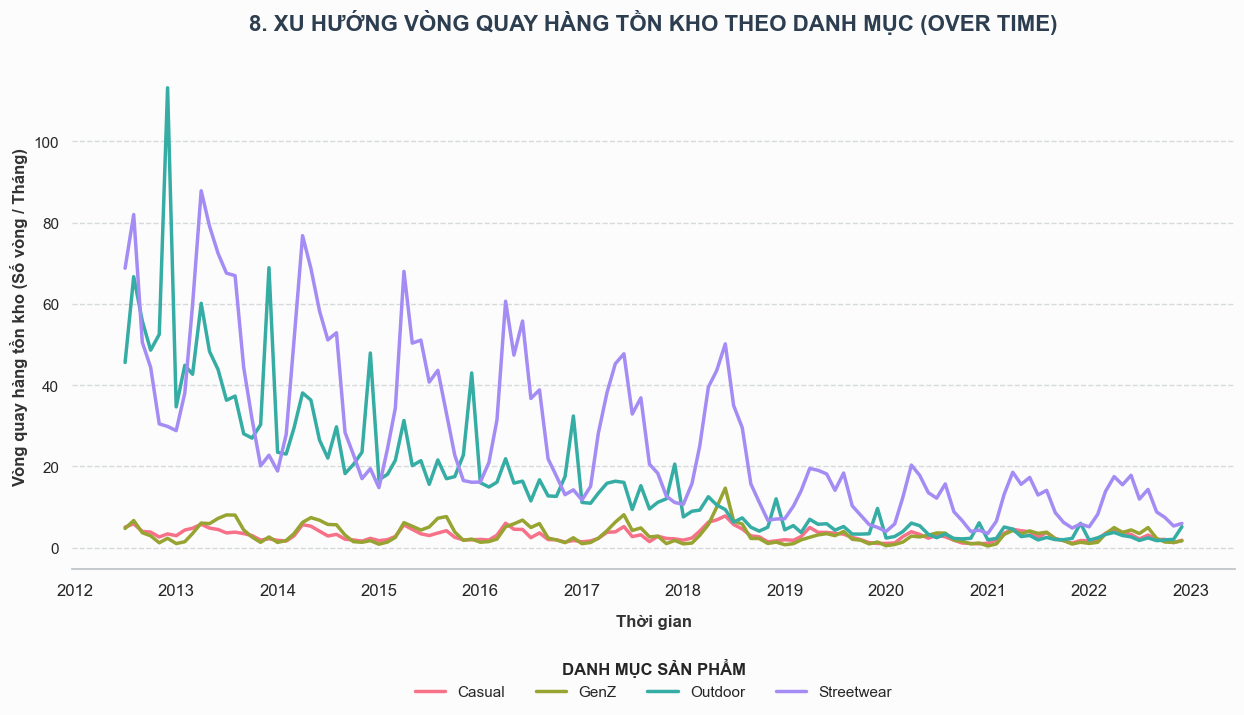

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

# Cài đặt giao diện hiện đại, nền sáng
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

try:
    # 1. ĐỌC DỮ LIỆU (CHỈ CẦN FILE INVENTORY LÀ ĐỦ)
    df = pd.read_csv('../dataset/inventory.csv')

    # Xử lý thời gian: Chuyển snapshot_date về ngày đầu tiên của tháng để dễ vẽ biểu đồ
    df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
    df['Month_Start'] = df['snapshot_date'].dt.to_period('M').dt.to_timestamp()

    # 2. TÍNH TOÁN THEO THÁNG (Không cần merge nữa)
    # Tính Tổng bán và Tồn kho trung bình của từng danh mục trong mỗi tháng
    monthly_summary = df.groupby(['Month_Start', 'category']).agg(
        Total_Sold=('units_sold', 'sum'),
        Avg_Stock=('stock_on_hand', 'mean')
    ).reset_index()

    # Xử lý lỗi chia cho 0 nếu tháng đó không có tồn kho
    monthly_summary['Avg_Stock'] = monthly_summary['Avg_Stock'].replace(0, 1)

    # Tính Tỷ lệ vòng quay (Turnover Rate)
    monthly_summary['Turnover_Rate'] = monthly_summary['Total_Sold'] / monthly_summary['Avg_Stock']

    # Xoay bảng (Pivot) để vẽ biểu đồ đường nhiều lớp
    pivot_df = monthly_summary.pivot(index='Month_Start', columns='category', values='Turnover_Rate').fillna(0)

    # 3. VẼ BIỂU ĐỒ ĐƯỜNG (LINE CHART)
    fig, ax = plt.subplots(figsize=(15, 8))
    
    colors = sns.color_palette("husl", len(pivot_df.columns))
    
    # Vẽ các đường xu hướng
    for idx, col in enumerate(pivot_df.columns):
        ax.plot(pivot_df.index, pivot_df[col], linewidth=2.5, 
                label=col, color=colors[idx])

    # Cấu hình trục Y
    ax.set_ylabel('Vòng quay hàng tồn kho (Số vòng / Tháng)', fontsize=12, fontweight='bold', color='#333333')
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax.set_axisbelow(True)

    # Cấu hình trục X theo Timeline
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', which='major', labelsize=12, pad=10, length=0)
    
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', which='minor', length=5, color='#bdc3c7', width=1.5) 
    ax.set_xlabel('Thời gian', fontsize=12, fontweight='bold', labelpad=12, color='#333333')

    # Dọn dẹp viền biểu đồ
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#bdc3c7')

    # Xử lý Legend
    ax.legend(title='DANH MỤC SẢN PHẨM', loc='upper center', bbox_to_anchor=(0.5, -0.15), 
              ncol=min(5, len(pivot_df.columns)), frameon=False, fontsize=11, 
              title_fontproperties={'weight':'bold'})

    plt.title('8. XU HƯỚNG VÒNG QUAY HÀNG TỒN KHO THEO DANH MỤC (OVER TIME)', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.25)
    
    plt.show()

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file dữ liệu - {e}")
except KeyError as e:
    print(f"Lỗi KeyError: Thiếu cột {e}. Vui lòng kiểm tra lại cấu trúc file inventory.csv của bạn.")